# Data overview

In [9]:
import pandas as pd
import json
from tqdm import tqdm
from explain import *
from pathlib import Path

In [10]:
collection,genre_suffix = 'blb',''
if collection == 'blb':
  genre_suffix = '_with_genre'

TargetMaskedToken = 'machine' # the token to be masked in the target sentence

originalFolder = 'masking_data' # change to '.' when working in colab
dataPath = 'input_data' # change to '.' when working in colab 
processedFolder = 'gradient_data' # change '.' when working in colab
predCol = "pred_bert_1760_1900"
resultType = 'pred_kw_filtered' # pred | pred_kw_filter

print(f"This analysis focuses on '{TargetMaskedToken}'.")

This analysis focuses on 'machine'.


In [11]:
df_sent_all = pd.read_csv(f'{originalFolder}/{collection}_{TargetMaskedToken}_clusters{genre_suffix}.tsv', index_col=0, sep='\t').reset_index(drop=True)
print(f'We have {df_sent_all.shape[0]} sentences for the target token {TargetMaskedToken} in the {collection} collection.')

df_sent_dedup = pd.read_csv(f'{originalFolder}/{collection}_{TargetMaskedToken}_clusters{genre_suffix}_deduplicated.tsv', index_col=0, sep='\t').reset_index(drop=True)
print(f'We have {df_sent_dedup.shape[0]} unique sentences for the target token {TargetMaskedToken} in the {collection} collection.')


We have 131002 sentences for the target token machine in the blb collection.
We have 77907 unique sentences for the target token machine in the blb collection.


In [41]:
# load the original sentences with the predicted tokens
df_sent = pd.read_csv(f'{dataPath}/{collection}_{TargetMaskedToken}{genre_suffix}_{resultType}.tsv', index_col=0, sep='\t').reset_index(drop=True)
print(f'We have {df_sent.shape[0]} sentences for the target token {TargetMaskedToken} in the {collection} collection.')
df_ig = pd.read_csv(f'{processedFolder}/results_{collection}_{TargetMaskedToken}_{resultType}_processed.csv', index_col=0 )
print(f'We have {df_ig.shape[0]} explanations for the target token {TargetMaskedToken} in the {collection} collection.')


We have 19003 sentences for the target token machine in the blb collection.
We have 2173047 explanations for the target token machine in the blb collection.


In [80]:
with open('input_data/250_freq_pred_KB_edit.txt') as f:
    human_words = f.read().splitlines()


In [81]:
df_sent['pred_bert_1760_1900_human'] = df_sent['pred_bert_1760_1900'].apply(
        lambda x: {w:s for w, s in dict(eval(x)).items() if w in human_words})

In [82]:
df_sent.shape

(19003, 35)

In [83]:
df_sent_filtered = df_sent[df_sent['pred_bert_1760_1900_human'].apply(lambda x: max(x.values()) > 0.2)]

ValueError: max() iterable argument is empty

In [ ]:
df_sent_filtered.head(3)

,article_path,identifier,date,shelfmarks,publisher,title,edition,contributors,creators,prevSentence,...,artisan_1760_1900,woman_1760_1900,machine_contemporary,boy_contemporary,girl_contemporary,slave_contemporary,artisan_contemporary,woman_contemporary,genre,pred_bert_1760_1900_human
2,000302544_01_text.json,302544,1889,British Library HMNTS 012633.m.31.,NaN,"To Call Her Mine, etc. (Katharine Regina.-'Self or Bearer.') [With plates.]",NaN,NaN,"Besant, Walter - Sir",In a smaller room at the back a forewoman was at work .,...,0.353,0.773,0.602,0.272,0.309,0.227,0.328,0.391,Fiction,"{'women': 0.45, 'girls': 0.3, 'ladies': 0.09, 'people': 0.03, 'men': 0.03, 'hands': 0.02, 'children': 0.01, 'assistants': 0.0, 'workers': 0.0, 'persons': 0.0, 'boys': 0.0, '##men': 0.0, 'masters':..."
4,000302544_01_text.json,302544,1889,British Library HMNTS 012633.m.31.,NaN,"To Call Her Mine, etc. (Katharine Regina.-'Self or Bearer.') [With plates.]",NaN,NaN,"Besant, Walter - Sir",Mr . Murridge was disappointed that his son had no passion for anything .,...,0.312,0.457,0.613,0.269,0.261,0.241,0.306,0.328,Fiction,"{'man': 0.4, 'boy': 0.06, 'child': 0.05, 'fool': 0.04, 'master': 0.02, 'gentleman': 0.01, 'blacksmith': 0.0, 'mechanic': 0.0, 'woman': 0.0, 'genius': 0.0, 'giant': 0.0, 'lad': 0.0, 'soldier': 0.0}"
5,000302544_01_text.json,302544,1889,British Library HMNTS 012633.m.31.,NaN,"To Call Her Mine, etc. (Katharine Regina.-'Self or Bearer.') [With plates.]",NaN,NaN,"Besant, Walter - Sir","Dick was no fool , but he did his work like a machine ; he took no interest in his work ; he was spiritless .",...,0.233,0.434,0.123,0.231,0.207,0.205,0.144,0.248,Fiction,"{'man': 0.38, 'child': 0.09, 'fool': 0.06, 'king': 0.06, 'boy': 0.05, 'gentleman': 0.03, 'genius': 0.02, 'poet': 0.01, 'philosopher': 0.01, 'giant': 0.01, 'hero': 0.01, 'god': 0.01, 'mortal': 0.01..."


<Axes: title={'center': 'Number of sentences per year for the target token machine.'}, xlabel='Year', ylabel='Number of sentences'>

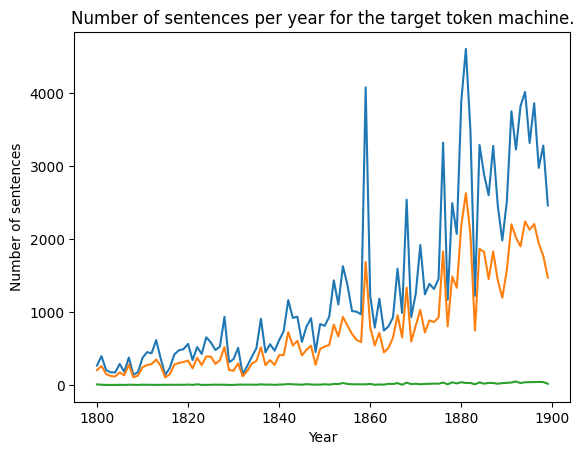

In [84]:
df_sent_all.groupby('date').size().loc[1800:1899].plot( title=f'Number of sentences per year for the target token {TargetMaskedToken}.', ylabel='Number of sentences', xlabel='Year')
df_sent_dedup.groupby('date').size().loc[1800:1899].plot(  ylabel='Number of sentences', xlabel='Year')
df_sent_filtered.groupby('date').size().loc[1800:1899].plot(  ylabel='Number of sentences', xlabel='Year')

<Axes: title={'center': 'Proportion of sentences with the target token machine that are unique per year.'}, xlabel='Year', ylabel='Proportion of unique sentences'>

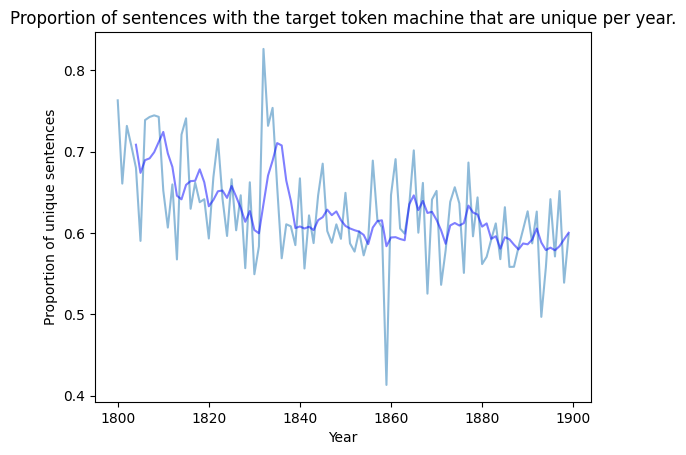

In [85]:
(df_sent_dedup.groupby('date').size()/df_sent_all.groupby('date').size()).loc[1800:1899].plot(alpha=0.5, title=f'Proportion of sentences with the target token {TargetMaskedToken} that are unique per year.', ylabel='Proportion of unique sentences', xlabel='Year')
(df_sent_dedup.groupby('date').size()/df_sent_all.groupby('date').size()).loc[1800:1899].rolling(window=5).mean().plot(color='blue', alpha=0.5, title=f'Proportion of sentences with the target token {TargetMaskedToken} that are unique per year.', ylabel='Proportion of unique sentences', xlabel='Year')

In [86]:
df_sent_dedup['decade'] = df_sent_dedup['date'].apply(lambda x: int(x/10)*10)
df_sent['decade'] = df_sent['date'].apply(lambda x: int(x/10)*10)

<Axes: >

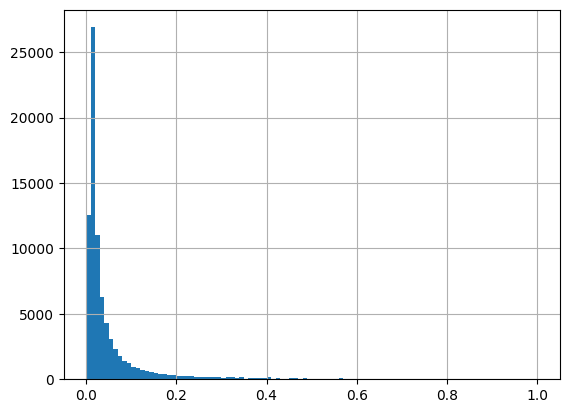

In [87]:
import itertools
scores = list(itertools.chain.from_iterable(df_sent['pred_bert_1760_1900_human'].apply(lambda x: list(x.values()))))
pd.Series(scores).hist(bins=100)

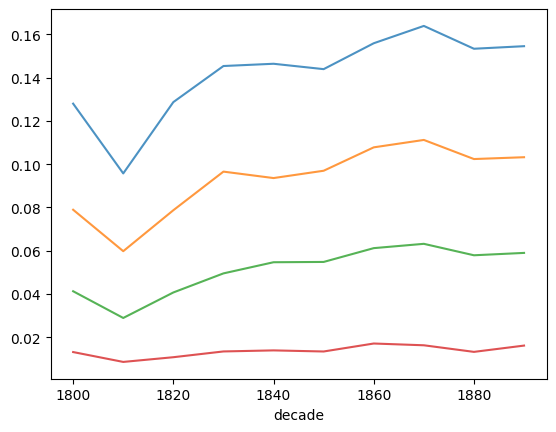

In [91]:
time_unit = 'decade' # change to 'date' for yearly analysis
thresholds = [0.05, 0.1, 0.2, 0.5]
for threshold in thresholds:
    df_sent_filtered = df_sent[df_sent['pred_bert_1760_1900_human'].apply(lambda x: max(list(x.values())+[.0]) > threshold)]
    (df_sent_filtered.groupby(time_unit).size()/df_sent_dedup.groupby(time_unit).size()).loc[1800:1899].plot(alpha=0.8, title=f'', xlabel=f'{time_unit}')
#(df_sent.groupby(time_unit).size()/df_sent_dedup.groupby(time_unit).size()).loc[1800:1899].rolling(window=10).mean().plot(color='blue', alpha=0.5, title=f'Proportion of sentences with the target token {TargetMaskedToken} that are unique per {time_unit}.', ylabel='Proportion of unique sentences', xlabel=f'{time_unit}')

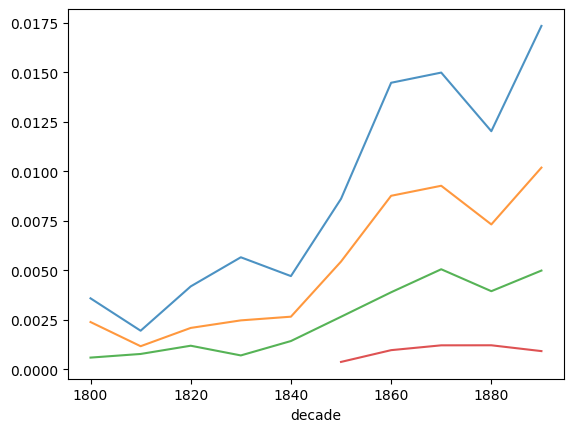

In [101]:
time_unit = 'decade' # change to 'date' for yearly analysis
thresholds = [0.05, 0.1, 0.2, 0.5]
wordList = ['child','children', 'boy','boys','girl','girls']
for threshold in thresholds:
    df_sent_filtered = df_sent[df_sent['pred_bert_1760_1900_human'].apply(
        lambda x: max(list({w:s for w,s in x.items() if w in wordList}.values())+[.0]) > threshold
                )
            ]
    (df_sent_filtered.groupby(time_unit).size() / df_sent_dedup.groupby(time_unit).size()).loc[1800:1899].plot(alpha=0.8, title=f'', xlabel=f'{time_unit}')


In [98]:
from collections import Counter
thresholds = 0.5
df_sent_filtered = df_sent[df_sent['pred_bert_1760_1900_human'].apply(lambda x: max(list(x.values())+[.0]) > threshold)]
    

kw_filter = open(f'{dataPath}/250_freq_pred_KB_edit.txt').read().splitlines()
preds = Counter([w for l in df_sent_filtered['pred_bert_1760_1900'].values for w,s in eval(l) if (w in kw_filter) & (s > threshold) ])

<Axes: title={'center': 'Top 100 predicted tokens for the target token machine.'}, xlabel='Predicted token', ylabel='Count'>

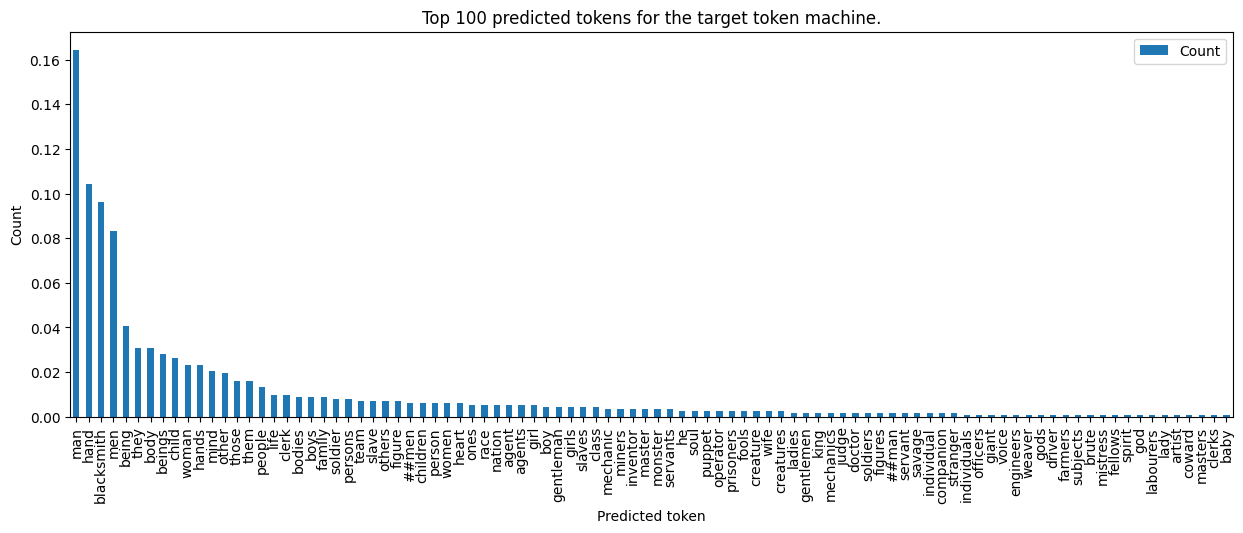

In [99]:
pd.DataFrame([(w, c/len(df_sent_filtered)) for w, c in preds.most_common(100)]
             ).rename(columns={0: 'Predicted token', 1: 'Count'}
                      ).set_index('Predicted token'
                                  ).plot(kind='bar', title=f'Top 100 predicted tokens for the target token {TargetMaskedToken}.', 
                                         ylabel='Count', xlabel='Predicted token', figsize=(15,5))

In [94]:
# check if ids are aligned between gradient data and sentences
print(df_ig['id'].nunique(), df_sent.shape[0])
print(df_ig[df_ig['id'] == 0].Token, df_sent.iloc[0].currentSentence) 

19003 19003
0               "
1            upon
2             the
3          ground
4               -
          ...    
137    fanatacism
138            of
139     crusaders
140             .
141             "
Name: Token, Length: 142, dtype: str " Upon the ground - where they had kneeled, His men would die or win the field, — " and friends and adversaries alike bear testimony, that in his camp, — " the most rigid discipline was found in company with the fiercest resolution; that his troops moved to victory with the precision of machines, while burning with the wildest fanatacism of crusaders. "


In [95]:
# check if ids are aligned between gradient data and sentences
print(df_ig['id'].nunique(), df_sent.shape[0])
print(df_ig[df_ig['id'] == 0].Token, df_sent.iloc[0].currentSentence) 

19003 19003
0               "
1            upon
2             the
3          ground
4               -
          ...    
137    fanatacism
138            of
139     crusaders
140             .
141             "
Name: Token, Length: 142, dtype: str " Upon the ground - where they had kneeled, His men would die or win the field, — " and friends and adversaries alike bear testimony, that in his camp, — " the most rigid discipline was found in company with the fiercest resolution; that his troops moved to victory with the precision of machines, while burning with the wildest fanatacism of crusaders. "


In [96]:

targetTokens = ['man','men']
df_comparisonConcept = df_ig[
    (df_ig['Target'].isin(targetTokens)) # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
                ].groupby('Token').agg(
                        count=('id', 'count'),identifiers=('id', set),avg_score=('Score', 'mean')
                    ).reset_index()


In [97]:
# please note that this repeats sentences, this acros all sentences with all the filtered keywords
min_count = 10
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_score', ascending=False)
df_result.head(20)

,Token,count,identifiers,avg_score
5312,engines,46,"{2695, 8201, 16011, 14480, 14481, 11411, 4373, 15509, 14455, 18327, 11161, 11930, 18331, 16291, 11940, 7471, 10160, 5426, 14898, 693, 5814, 18109, 18111, 12865, 18117, 5069, 18381, 5843, 18135, 18...",0.402115
1821,beast,11,"{7008, 16704, 13381, 17125, 1197, 8373, 13466, 2971, 15901}",0.400695
1067,animal,44,"{2950, 5638, 16136, 4495, 6291, 13591, 17944, 6042, 14877, 17949, 14880, 3745, 418, 9507, 7461, 6183, 2728, 15276, 14260, 7741, 5694, 3007, 9410, 4553, 458, 14665, 4684, 10831, 4690, 12372, 5719, ...",0.363326
12658,ry,11,"{15774, 13862, 5224, 6057, 10792, 8683, 6483, 13844, 2359, 1662, 16351}",0.353351
2250,boys,29,"{4997, 5900, 2447, 29, 6051, 14630, 4263, 15532, 11315, 18175, 3512, 4667, 5439, 4161, 9282, 11979, 13262, 4561, 11475, 9951, 1379, 13156, 8805, 16619, 17134, 14580, 1791}",0.345765
7832,infernal,29,"{6658, 11269, 9485, 4241, 16789, 17045, 4761, 4378, 4256, 14627, 11559, 10154, 4012, 8125, 5446, 5447, 6086, 11467, 10195, 7515, 14685, 14686, 994, 11363, 13410, 6377, 11634, 2294, 6140}",0.344877
2520,calculating,62,"{7425, 7426, 4355, 4357, 16657, 15380, 15894, 5911, 18583, 13083, 14491, 2590, 2591, 5152, 15006, 4898, 14626, 805, 4521, 1714, 2099, 6707, 7859, 6070, 16819, 3897, 12219, 17212, 2624, 7873, 13504...",0.342867
6008,fighting,65,"{17580, 12421, 13961, 18570, 13585, 7826, 8722, 10516, 3094, 10518, 13466, 10907, 3228, 13211, 11810, 5923, 12199, 8490, 3243, 3372, 10666, 12078, 3631, 10031, 10544, 14892, 10035, 4660, 5813, 100...",0.325301
9474,military,36,"{9357, 13837, 9488, 17690, 16412, 4126, 4127, 4260, 4900, 17573, 15657, 4010, 11563, 11818, 9903, 3635, 18740, 18878, 13375, 9408, 18369, 12227, 11972, 6597, 13510, 5831, 14023, 13387, 10829, 609,...",0.323209
1068,animals,39,"{2306, 16392, 17289, 10254, 2832, 17558, 2073, 2973, 1950, 13853, 16799, 6953, 7723, 1197, 3377, 11954, 16829, 11966, 13120, 2630, 12489, 11984, 14161, 4825, 6876, 11741, 10731, 11118, 12654, 1559...",0.317982


In [23]:
pd.set_option('display.max_colwidth', 200)
df_sent.iloc[list(df_result.loc[1821].identifiers)].currentSentence

7008     The jinrikishas were very ricketty ones, and two of them broke down beyond the power of straw rope, paper, and rice paste to remedy their defects; so that these usual Japanese applications in case...
16704                                                    He ceases to be either a machine or a beast of burden; he " learns to venerate himself, " and that is the first lesson of public and of private virtue.
13381    But it is im possible, from our point of sight, to contemplate with satisfaction a course of treatment which kept him in health only to reduce him to the condition of a working machine or a beast ...
17125                                                                                                                                             " Before I became this machine, and you a — " " A beast, John!
1197     It is criminal in him to be a man of iron, whom neither heat nor cold seems to affect, and of that machine like calibre which never Avearies. * It is an ad

In [24]:
modelName = "Livingwithmachines/bert_1760_1900"
explainer = MaskedLMExplainer(model_name=modelName, device=pick_device())

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: Livingwithmachines/bert_1760_1900
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [111]:
df_ig.columns

Index(['Token', 'Score', 'Target', 'id', 'Score_normalized',
       'mask_syntax_relation', 'mask_constituent_relation',
       'mask_token_distance', 'Target_position', 'Sentence_length'],
      dtype='str')

In [131]:
predictedToken = 'man'
contextToken = 'beast'
ids = df_ig[(df_ig['Token'].str.lower() == contextToken) & (df_ig['Target'].str.lower() == predictedToken)
                    ].sort_values('Score_normalized',ascending=False).id.values

In [132]:
ids

array([15901, 13466,  7008, 17125,  8373, 16704,  2971, 13381, 15901,
        8373,  1197])

In [138]:
idx = 15901
wordList = ['man','men']
sentence = df_sent.iloc[idx].maskedSentence
targets = list(set(df_ig[df_ig['id'] == idx].Target.unique()).intersection(set(wordList)))

In [139]:
print(f"Sentence: {sentence}")
print(f"Targets: {targets}")

Sentence: Did you ever see a hold Scoty as goes about with an ' aw Tker 's waggon . sellin ' religious books , and preachin ' on Sundays and week days , when ' e can get chaps to listen as ' ow 's there 's few to be saved , and it 's very onlike it 's them ?' THE SILENT SEA ■ 3i ' No , I never did !' ' And ' ave you some sort of a [MASK] and a beast as you can make a start with this very night ?' ' I could borrer the light ' Merican waggon as belongs to the place , and there 's a beast in the stable .
Targets: ['man']


In [140]:
target =targets[0]

In [141]:

highlight_context_tokens(explainer, sentence, target=target, word_agg="mean")

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_291829f24ac04a78a0e8e9254d5a3006">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>man</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'-0.011068\' style=\'background:rgba(229, 57, 53, 0.116); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>did</span> <span class=\'tok\' data-score=\'-0.013671\' style=\'background:rgba(229, 57, 53, 0.120); padding:2px 4px; margin:1

## 2D t-SNE visualization of BERT word embeddings

This section projects word embeddings to 2D with t-SNE.

- Input: a BERT model (or model name) and a list of words
- Output: a scatter plot with word labels

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from transformers import AutoModel, AutoTokenizer


def plot_word_embeddings_tsne(
    model_or_name,
    words,
    tokenizer=None,
    seed=42,
    figsize=(10, 7),
    backend="plotly",
    dims=2,
):
    """Project BERT word embeddings to 2D/3D with t-SNE and plot them."""
    if dims not in (2, 3):
        raise ValueError("dims must be 2 or 3")

    if isinstance(model_or_name, str):
        # Loading a model from disk can be memory-heavy.
        tokenizer = AutoTokenizer.from_pretrained(model_or_name)
        model = AutoModel.from_pretrained(model_or_name)
    else:
        model = model_or_name
        if tokenizer is None:
            raise ValueError("Please provide a tokenizer when passing a model instance.")

    embedding_weight = model.get_input_embeddings().weight.detach().cpu().numpy()

    vectors = []
    labels = []

    for word in words:
        token_ids = tokenizer.encode(word, add_special_tokens=False)
        if len(token_ids) == 0:
            continue

        # Average subword embeddings to represent the full word.
        word_vector = embedding_weight[token_ids].mean(axis=0)
        vectors.append(word_vector)
        labels.append(word)

    if len(vectors) < 2:
        raise ValueError("Need at least two valid words to run t-SNE.")

    x = np.vstack(vectors)
    perplexity = max(2, min(30, len(labels) - 1))

    tsne = TSNE(
        n_components=dims,
        init="pca",
        learning_rate="auto",
        perplexity=perplexity,
        random_state=seed,
    )
    coords = tsne.fit_transform(x)

    if backend.lower() == "plotly":
        try:
            import plotly.graph_objects as go

            if dims == 2:
                fig = go.Figure(
                    data=[
                        go.Scatter(
                            x=coords[:, 0],
                            y=coords[:, 1],
                            mode="markers+text",
                            text=labels,
                            textposition="top center",
                            marker={"size": 10, "opacity": 0.85},
                            hovertemplate="word=%{text}<br>x=%{x:.3f}<br>y=%{y:.3f}<extra></extra>",
                        )
                    ]
                )
                fig.update_layout(
                    title="t-SNE projection of BERT word embeddings (2D)",
                    xaxis_title="t-SNE dimension 1",
                    yaxis_title="t-SNE dimension 2",
                    template="plotly_white",
                    width=1000,
                    height=700,
                )
            else:
                fig = go.Figure(
                    data=[
                        go.Scatter3d(
                            x=coords[:, 0],
                            y=coords[:, 1],
                            z=coords[:, 2],
                            mode="markers+text",
                            text=labels,
                            marker={"size": 5, "opacity": 0.85},
                            hovertemplate="word=%{text}<br>x=%{x:.3f}<br>y=%{y:.3f}<br>z=%{z:.3f}<extra></extra>",
                        )
                    ]
                )
                fig.update_layout(
                    title="t-SNE projection of BERT word embeddings (3D)",
                    scene={
                        "xaxis_title": "t-SNE dim 1",
                        "yaxis_title": "t-SNE dim 2",
                        "zaxis_title": "t-SNE dim 3",
                    },
                    template="plotly_white",
                    width=1000,
                    height=760,
                )
            fig.show()
        except Exception as e:
            print(f"Plotly backend unavailable ({e}). Falling back to Matplotlib.")
            backend = "matplotlib"

    if backend.lower() == "matplotlib":
        if dims != 2:
            raise ValueError("Matplotlib backend in this helper supports dims=2 only. Use backend='plotly' for 3D.")

        plt.figure(figsize=figsize)
        plt.scatter(coords[:, 0], coords[:, 1], s=70, alpha=0.85)

        for i, label in enumerate(labels):
            plt.text(coords[i, 0], coords[i, 1], f" {label}", fontsize=10)

        plt.title("t-SNE projection of BERT word embeddings (2D)")
        plt.xlabel("t-SNE dimension 1")
        plt.ylabel("t-SNE dimension 2")
        plt.tight_layout()
        plt.show()

    return coords, labels

In [35]:
# Memory-safe example: reuse the model already loaded in `explainer`.
# Set dims = 2 or 3 to switch between 2D and 3D.
if not ("explainer" in globals() and hasattr(explainer, "model") and hasattr(explainer, "tokenizer")):
    raise RuntimeError(
        "`explainer` is not available. Run the model initialization cell first to avoid loading a second model copy."
    )

viz_dims = 2
word_file = f'{dataPath}/250_freq_pred_KB_edit.txt' if "dataPath" in globals() else 'input_data/250_freq_pred_KB_edit.txt'
words_for_tsne = open(word_file).read().splitlines()[:120]

coords, labels = plot_word_embeddings_tsne(
    explainer.model,
    words_for_tsne,
    tokenizer=explainer.tokenizer,
    seed=42,
    figsize=(12, 8),
    backend="plotly",
    dims=viz_dims,
)

## Automatic region detection in the 2D embedding plot

This section detects regions automatically from the 2D points and visualizes them in Plotly.

- Tries `HDBSCAN` first when available (automatic number of clusters)
- Falls back to `DBSCAN` when `hdbscan` is not installed
- Draws convex-hull boundaries for detected regions

In [36]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.colors import qualitative
from sklearn.cluster import DBSCAN
from scipy.spatial import ConvexHull


def _region_stats(cluster_labels):
    labels = np.asarray(cluster_labels)
    unique = set(labels.tolist())
    non_noise = labels[labels != -1]
    return {
        "n_points": int(labels.size),
        "n_noise": int((labels == -1).sum()),
        "n_non_noise": int((labels != -1).sum()),
        "n_regions": int(len(unique - {-1})),
        "noise_ratio": float((labels == -1).sum() / max(1, labels.size)),
    }


def detect_regions(
    coords,
    method="hdbscan",
    min_cluster_size=10,
    min_samples=2,
    eps=2.0,
    cluster_selection_epsilon=0.8,
    auto_expand_eps=True,
    allow_single_cluster=True,
):
    """Return cluster labels for coordinates using HDBSCAN or DBSCAN."""
    x = np.asarray(coords)
    if x.ndim != 2 or x.shape[1] not in (2, 3):
        raise ValueError("coords must have shape (n_points, 2) or (n_points, 3)")

    # Standardize coordinates so density params are more stable across 2D/3D.
    scale = x.std(axis=0, keepdims=True)
    scale[scale == 0] = 1.0
    x_scaled = (x - x.mean(axis=0, keepdims=True)) / scale

    hdbscan_error = None
    if method.lower() == "hdbscan":
        try:
            import hdbscan

            model = hdbscan.HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                metric="euclidean",
                cluster_selection_epsilon=cluster_selection_epsilon,
                allow_single_cluster=allow_single_cluster,
                cluster_selection_method="eom",
            )
            labels = model.fit_predict(x_scaled)
            stats = _region_stats(labels)

            # 3D embeddings can be sparse; retry with softer settings if everything is noise.
            if x.shape[1] == 3 and stats["n_non_noise"] == 0:
                soft_model = hdbscan.HDBSCAN(
                    min_cluster_size=max(3, min_cluster_size // 2),
                    min_samples=1,
                    metric="euclidean",
                    cluster_selection_epsilon=max(cluster_selection_epsilon, 0.4),
                    allow_single_cluster=True,
                    cluster_selection_method="leaf",
                )
                soft_labels = soft_model.fit_predict(x_scaled)
                soft_stats = _region_stats(soft_labels)
                if soft_stats["n_non_noise"] > stats["n_non_noise"]:
                    labels = soft_labels
                    stats = soft_stats

            return labels, "hdbscan", {"stats": stats, "hdbscan_error": None}
        except Exception as e:
            hdbscan_error = str(e)

    def run_dbscan(eps_value):
        model = DBSCAN(eps=eps_value, min_samples=min_samples, metric="euclidean")
        labels_ = model.fit_predict(x_scaled)
        return labels_, _region_stats(labels_)

    labels, stats = run_dbscan(eps)
    method_used = "dbscan"
    chosen_eps = eps

    if auto_expand_eps and stats["n_non_noise"] == 0:
        # Expand eps progressively to avoid the "all-noise" outcome.
        eps_candidates = np.linspace(eps * 1.25, eps * 4.0, 8)
        best_labels = labels
        best_stats = stats
        best_eps = eps

        for eps_candidate in eps_candidates:
            cand_labels, cand_stats = run_dbscan(float(eps_candidate))
            if cand_stats["n_non_noise"] > best_stats["n_non_noise"]:
                best_labels = cand_labels
                best_stats = cand_stats
                best_eps = float(eps_candidate)
            if cand_stats["n_non_noise"] > 0 and cand_stats["n_regions"] >= 1:
                best_labels = cand_labels
                best_stats = cand_stats
                best_eps = float(eps_candidate)
                break

        labels = best_labels
        stats = best_stats
        chosen_eps = best_eps
        if chosen_eps != eps:
            method_used = "dbscan-auto-eps"

    diagnostics = {
        "stats": stats,
        "hdbscan_error": hdbscan_error,
        "dbscan_eps": float(chosen_eps),
    }
    return labels, method_used, diagnostics


def plot_detected_regions(coords, words, cluster_labels, dims=2, title="Detected Regions in Embedding Space"):
    """Interactive Plotly scatter with optional hull boundaries for 2D/3D."""
    x = np.asarray(coords)
    words = list(words)
    cluster_labels = np.asarray(cluster_labels)

    if dims not in (2, 3):
        raise ValueError("dims must be 2 or 3")
    if x.ndim != 2 or x.shape[1] != dims:
        raise ValueError("coords dimensionality does not match dims")
    if len(words) != len(x) or len(cluster_labels) != len(x):
        raise ValueError("coords, words, and cluster_labels must have the same length")

    unique_labels = sorted(set(cluster_labels.tolist()))
    palette = qualitative.Safe + qualitative.Set3 + qualitative.Dark24
    cluster_color = {}
    color_idx = 0
    for lab in unique_labels:
        if lab == -1:
            cluster_color[lab] = "#8c8c8c"
        else:
            cluster_color[lab] = palette[color_idx % len(palette)]
            color_idx += 1

    fig = go.Figure()

    for lab in unique_labels:
        idx = np.where(cluster_labels == lab)[0]
        name = "noise" if lab == -1 else f"region {lab}"
        color = cluster_color[lab]

        if dims == 2:
            fig.add_trace(
                go.Scatter(
                    x=x[idx, 0],
                    y=x[idx, 1],
                    mode="markers+text",
                    text=[words[i] for i in idx],
                    textposition="top center",
                    marker={"size": 10, "opacity": 0.9, "color": color},
                    name=name,
                    hovertemplate="word=%{text}<br>x=%{x:.3f}<br>y=%{y:.3f}<extra></extra>",
                )
            )

            if lab == -1 or len(idx) < 3:
                continue

            pts = x[idx]
            if np.unique(pts, axis=0).shape[0] < 3:
                continue

            try:
                hull = ConvexHull(pts)
                hull_pts = pts[hull.vertices]
                hull_pts = np.vstack([hull_pts, hull_pts[0]])
                fig.add_trace(
                    go.Scatter(
                        x=hull_pts[:, 0],
                        y=hull_pts[:, 1],
                        mode="lines",
                        fill="toself",
                        line={"color": color, "width": 1.5},
                        fillcolor=color,
                        opacity=0.16,
                        showlegend=False,
                        hoverinfo="skip",
                    )
                )
            except Exception:
                pass

        else:
            fig.add_trace(
                go.Scatter3d(
                    x=x[idx, 0],
                    y=x[idx, 1],
                    z=x[idx, 2],
                    mode="markers+text",
                    text=[words[i] for i in idx],
                    marker={"size": 5, "opacity": 0.92, "color": color},
                    name=name,
                    hovertemplate="word=%{text}<br>x=%{x:.3f}<br>y=%{y:.3f}<br>z=%{z:.3f}<extra></extra>",
                )
            )

            if lab == -1 or len(idx) < 4:
                continue

            pts = x[idx]
            if np.unique(pts, axis=0).shape[0] < 4:
                continue

            try:
                hull = ConvexHull(pts)
                simplices = hull.simplices
                fig.add_trace(
                    go.Mesh3d(
                        x=pts[:, 0],
                        y=pts[:, 1],
                        z=pts[:, 2],
                        i=simplices[:, 0],
                        j=simplices[:, 1],
                        k=simplices[:, 2],
                        color=color,
                        opacity=0.22,
                        flatshading=True,
                        name=f"{name} boundary",
                        hoverinfo="skip",
                        showscale=False,
                        showlegend=False,
                    )
                )
            except Exception:
                pass

    if dims == 2:
        fig.update_layout(
            title=title,
            xaxis_title="t-SNE dimension 1",
            yaxis_title="t-SNE dimension 2",
            template="plotly_white",
            width=1100,
            height=760,
        )
    else:
        fig.update_layout(
            title=title,
            scene={
                "xaxis_title": "t-SNE dim 1",
                "yaxis_title": "t-SNE dim 2",
                "zaxis_title": "t-SNE dim 3",
            },
            template="plotly_white",
            width=1100,
            height=800,
        )

    fig.show()


def detect_and_plot_regions(
    coords,
    words,
    dims=2,
    method="hdbscan",
    min_cluster_size=10,
    min_samples=2,
    eps=2.0,
    cluster_selection_epsilon=0.8,
    auto_expand_eps=True,
    allow_single_cluster=True,
):
    cluster_labels, method_used, diagnostics = detect_regions(
        coords,
        method=method,
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        eps=eps,
        cluster_selection_epsilon=cluster_selection_epsilon,
        auto_expand_eps=auto_expand_eps,
        allow_single_cluster=allow_single_cluster,
    )

    region_df = (
        pd.DataFrame({"word": words, "region": cluster_labels})
        .sort_values(["region", "word"], ascending=[True, True])
        .reset_index(drop=True)
    )

    summary = (
        region_df.groupby("region")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    plot_detected_regions(
        coords,
        words,
        cluster_labels,
        dims=dims,
        title=f"Detected Regions in Embedding Space ({method_used.upper()}, {dims}D)",
    )

    if diagnostics.get("hdbscan_error"):
        print("HDBSCAN unavailable; using DBSCAN fallback.")
    print(
        f"Method: {method_used} | Regions: {diagnostics['stats']['n_regions']} | "
        f"Noise: {diagnostics['stats']['n_noise']}/{diagnostics['stats']['n_points']} | "
        f"eps={diagnostics.get('dbscan_eps', eps):.3f}"
    )

    print("\nWords per region:")
    for region, group in region_df.groupby("region", sort=True):
        name = "noise" if region == -1 else f"region {region}"
        words_in_region = group["word"].tolist()
        print(f"{name} ({len(words_in_region)}): {', '.join(words_in_region)}")

    return cluster_labels, summary, diagnostics, region_df

In [39]:
# Coarser settings for larger regions.
# Set dims = 2 or 3 to switch region visualization mode.
region_dims = 2

cluster_labels, region_summary, region_diagnostics, region_words = detect_and_plot_regions(
    coords,
    labels,
    dims=region_dims,
    method="hdbscan",
    min_cluster_size=10,
    min_samples=2,
    eps=1.8,
    cluster_selection_epsilon=0.5,
    auto_expand_eps=True,
    allow_single_cluster=True,
)

region_summary

Method: hdbscan | Regions: 1 | Noise: 15/120 | eps=1.800

Words per region:
noise (15): bodies, body, fellow, fellows, figure, figures, god, gods, hand, hands, lad, master, masters, mistress, puppet
region 0 (105): ##man, ##men, agent, agents, angels, artist, assistants, baby, being, beings, boy, boys, brute, character, child, children, citizen, class, clerk, clerks, creature, creatures, demon, demons, devil, doctor, driver, engineers, family, farmer, farmers, fool, fools, friend, friends, genius, gentleman, gentlemen, ghost, giant, giants, girl, girls, he, heart, hero, individual, individuals, inventor, king, labourers, ladies, lady, life, madman, man, mechanic, mechanics, men, mind, miners, monster, mortal, nation, officer, officers, ones, operator, other, others, peasant, people, person, persons, philosopher, poet, press, prisoner, puppets, race, rider, savage, servant, servants, slave, slaves, soldier, soldiers, soul, spectator, spirit, stranger, student, subjects, teacher, team, t

,region,count
0,0,105
1,-1,15
